# Breast Cancer Classification with Logistic Regression

## Introduction

This notebook demonstrates a complete workflow for building a **binary classifier** using **Logistic Regression** to predict whether a breast tumor is **benign** or **malignant**. The dataset used is the **Breast Cancer Wisconsin (Diagnostic) Data Set**, which contains 30 numerical features computed from images of fine needle aspirates (FNA) of breast masses.

We focus on the following steps:

1. **Data Exploration:** Analyze feature distributions and calculate summary statistics (max, min, mean).  
2. **Data Preprocessing:** Split the dataset into training and testing sets and standardize features if necessary.  
3. **Model Training:** Train a logistic regression model on the training data.  
4. **Evaluation:** Evaluate the model using metrics like precision, recall, F1-score, ROC-AUC, and visualize with ROC curves and threshold tuning plots.  
5. **Threshold Tuning:** Find the optimal probability threshold that maximizes F1-score and balances precision and recall.  
6. **Visualization:** Explore confusion matrices, probability distributions, and precision-recall curves.  
7. **Model Saving:** Save the trained model with the tuned threshold for future predictions.

By the end of this notebook, you will have a **fully trained and evaluated logistic regression model** with optimal threshold tuning for improved classification performance.  


## Imports

We start by importing all the necessary libraries for data manipulation, visualization, model training, evaluation, and saving:

- **pandas, numpy:** Data handling and numerical operations  
- **matplotlib.pyplot, seaborn:** Visualizations  
- **joblib:** Saving and loading models  
- **scikit-learn modules:** 
  - `train_test_split` for splitting the dataset  
  - `StandardScaler` and `LabelEncoder` for preprocessing  
  - `LogisticRegression` for model training  
  - Metrics like `confusion_matrix`, `classification_report`, `roc_auc_score`, `roc_curve`, `precision_recall_curve`, `f1_score`, `recall_score`, `precision_score` for evaluation  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, f1_score, recall_score, precision_score

## Data Loading

We load the preprocessed dataset and create a copy for further analysis:

- The dataset is stored in `datasets/data-clean.csv`.  
- A copy of the dataframe is created to ensure the original data remains intact.  


In [2]:
data = pd.read_csv("datasets/data-clean.csv")
df = data.copy()

## Feature Statistics Visualization

We compute the **maximum, minimum, and mean** for each feature and visualize them:

- `max_`: Maximum value of each feature  
- `min_`: Minimum value of each feature  
- `mean_`: Mean value of each feature  

The resulting plot shows the variation of max, min, and mean across all features, helping us understand feature distributions and ranges.


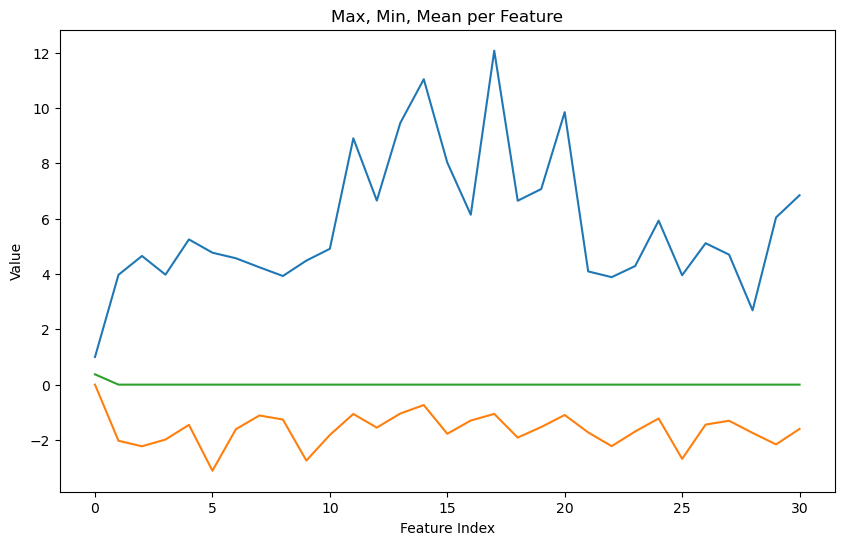

In [13]:
max_ = []
min_ = []
mean_ = []
for col in df.columns:
    max_.append(df[col].max())
    min_.append(df[col].min())
    mean_.append(df[col].mean())

mmm = np.array([max_, min_, mean_])
x = np.arange(1, len(df.columns) + 1)

plt.figure(figsize=(10,6))
plt.plot(mmm.T)
plt.xlabel("Feature Index")
plt.ylabel("Value")
plt.title("Max, Min, Mean per Feature")
plt.savefig("plots/Max, Min, Mean per Feature", dpi=300, bbox_inches='tight')
plt.show()

## Train-Test Split

We separate the dataset into features (`X`) and target (`y`), then split it into training and testing sets:

- **Features (`X`)**: All columns except `diagnosis`  
- **Target (`y`)**: The `diagnosis` column  
- **Split**: 80% training, 20% testing  
- **Stratified split**: Ensures the same proportion of benign and malignant samples in both sets  

We also print the shapes to confirm the split.


In [4]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


## Logistic Regression Training and Evaluation

We train a **Logistic Regression** model on the training data and evaluate its performance on the test set:

- `solver='liblinear'`: Suitable for smaller datasets  
- Predictions: `y_pred` (class labels), `y_prob` (probabilities for malignant class)  
- **Metrics reported**:
  - Confusion Matrix  
  - Classification Report (precision, recall, F1-score)  
  - ROC-AUC Score  
- **ROC Curve**: Visualizes the model's ability to distinguish between classes


Confusion Matrix:
 [[71  1]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC Score: 0.996362433862434


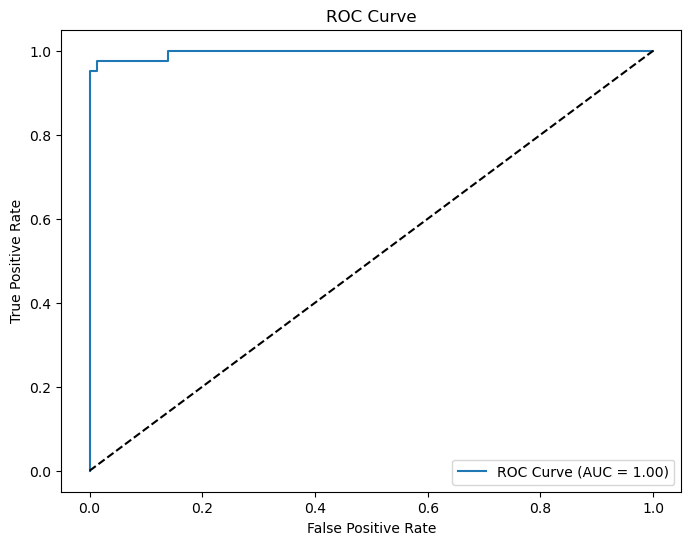

In [14]:
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("plots/ROC Curve", dpi=300, bbox_inches='tight')
plt.show()

## Precision, Recall, F1-score vs Threshold

We evaluate how **precision, recall, and F1-score** change across different probability thresholds:

- `thresholds`: Range from 0.0 to 1.0  
- Metrics are calculated for each threshold to understand the trade-offs  
- The **best F1-score threshold** is highlighted with a vertical dashed line  
- This plot helps in selecting a threshold that balances precision and recall for optimal performance


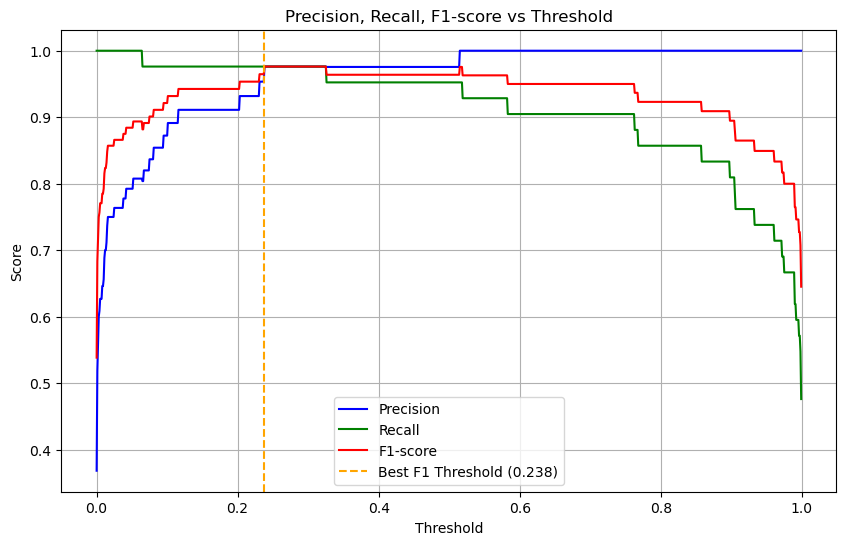

In [15]:
thresholds = np.arange(0.0, 1.0, 0.001)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))

plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls, label='Recall', color='green')
plt.plot(thresholds, f1s, label='F1-score', color='red')
plt.axvline(x=thresholds[np.argmax(f1s)], color='orange', linestyle='--', label=f'Best F1 Threshold ({thresholds[np.argmax(f1s)]:.3f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1-score vs Threshold')
plt.legend()
plt.grid(True)
plt.savefig("plots/Precision, Recall, F1-score vs Threshold", dpi=300, bbox_inches='tight')
plt.show()

## Threshold Tuning

We search for the **optimal probability threshold** that maximizes the chosen metric (`f1` by default):

- `thresholds`: A fine-grained range between 0.22 and 0.35 where metrics are balanced  
- For each threshold, we calculate the selected metric (`f1`, `precision`, or `recall`)  
- The **best threshold** is the one that achieves the highest metric score  
- `y_pred_best`: Predictions using the tuned threshold  


In [7]:
metric_to_optimize = 'f1'
thresholds = np.arange(0.22, 0.35, 0.00001)

best_threshold = thresholds[0]
best_metric = 0

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    if metric_to_optimize == 'f1':
        score = f1_score(y_test, y_pred_thresh)
    elif metric_to_optimize == 'recall':
        score = recall_score(y_test, y_pred_thresh)
    elif metric_to_optimize == 'precision':
        score = precision_score(y_test, y_pred_thresh)
    
    if score > best_metric:
        best_metric = score
        best_threshold = t

y_pred_best = (y_prob >= best_threshold).astype(int)


print(f"Best threshold: {best_threshold}")
print(f"Best {metric_to_optimize} score: {best_metric:.4f}")

Best threshold: 0.2371100000000171
Best f1 score: 0.9762


## Confusion Matrix Heatmap

We visualize the **confusion matrix** for the predictions made using the **best threshold**:

- Rows: Actual labels  
- Columns: Predicted labels  
- Heatmap colors indicate the number of samples in each category  
- Threshold used is displayed in the title to indicate the tuned cutoff for classification


Confusion Matrix:
 [[71  1]
 [ 1 41]]


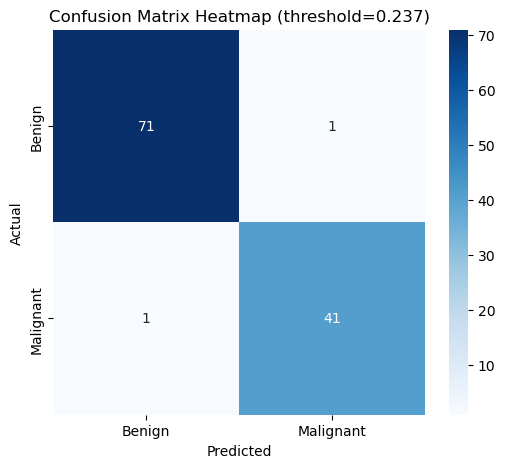

In [16]:
cm = confusion_matrix(y_test, y_pred_best)
print("Confusion Matrix:\n", cm)
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix Heatmap (threshold={best_threshold:.3f})')
plt.savefig("plots/Confusion Matrix Heatmap with Threshold", dpi=300, bbox_inches='tight')
plt.show()

## ROC Curve

We plot the **ROC Curve** using the predicted probabilities:

- **True Positive Rate (TPR)** vs **False Positive Rate (FPR)**  
- The **diagonal line** represents a random classifier  
- **AUC (Area Under the Curve)** quantifies the overall model performance  
- Helps visualize the trade-off between sensitivity and specificity


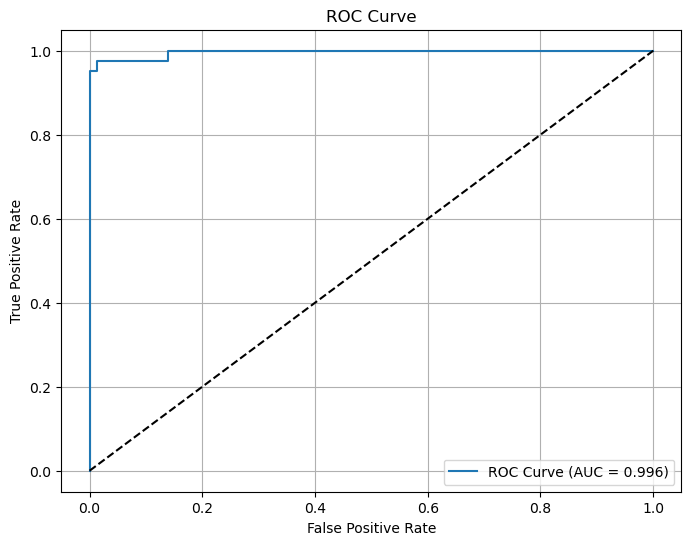

In [9]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

## Precision-Recall Curve

We visualize the **Precision-Recall trade-off**:

- **Precision** vs **Recall** across different thresholds  
- The **orange point** indicates the performance at the **tuned threshold**  
- Helps evaluate model performance in imbalanced datasets and understand the effect of threshold tuning on precision and recall


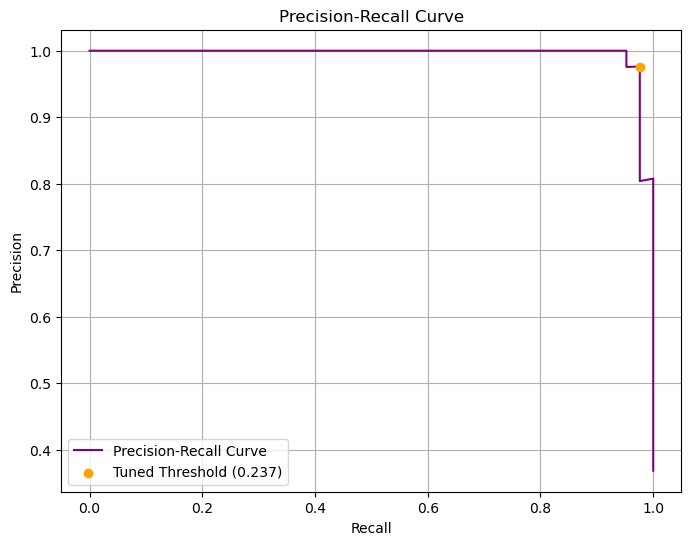

In [17]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals, label='Precision-Recall Curve', color='purple')
plt.scatter(recall_score(y_test, y_pred_best), precision_score(y_test, y_pred_best), color='orange', label=f'Tuned Threshold ({best_threshold:.3f})', zorder=5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.savefig("plots/Precision-Recall Curve", dpi=300, bbox_inches='tight')
plt.show()

## Probability Distribution of Classes

We visualize the distribution of **predicted probabilities** for each class:

- Blue: Benign samples  
- Red: Malignant samples  
- **Orange dashed line**: Tuned threshold used for classification  
- Helps understand the separation between classes and the choice of threshold


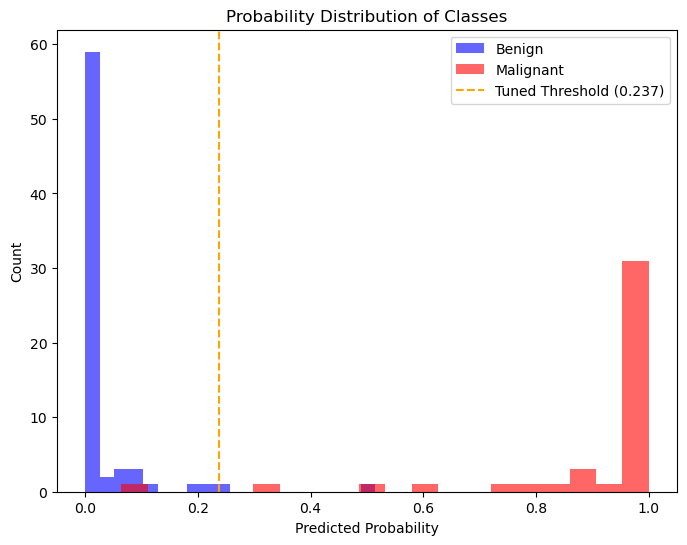

In [18]:
plt.figure(figsize=(8,6))
plt.hist(y_prob[y_test==0], bins=20, alpha=0.6, label='Benign', color='blue')
plt.hist(y_prob[y_test==1], bins=20, alpha=0.6, label='Malignant', color='red')
plt.axvline(best_threshold, color='orange', linestyle='--', label=f'Tuned Threshold ({best_threshold:.3f})')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution of Classes')
plt.legend()
plt.savefig("plots/Probability Distribution of Classes", dpi=300, bbox_inches='tight')
plt.show()

## Save Trained Model

The Logistic Regression model is saved along with the **tuned threshold**:

- Threshold is included in the filename up to 6 decimal places  
- File format: `.pkl` using **joblib**  
- Ensures reproducibility and easy loading for future predictions


In [12]:
threshold_str = f"{best_threshold:.6f}"
model_filename = f"models/model_T-{threshold_str}-T.pkl"
joblib.dump(model, model_filename)

print(f"Model saved as: {model_filename}")

Model saved as: models/model_T-0.237110-T.pkl


---